In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

In [2]:
df = pd.read_csv('8.2-)diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
outcome                     0
dtype: int64

In [6]:
df['outcome'].value_counts()

outcome
0    500
1    268
Name: count, dtype: int64

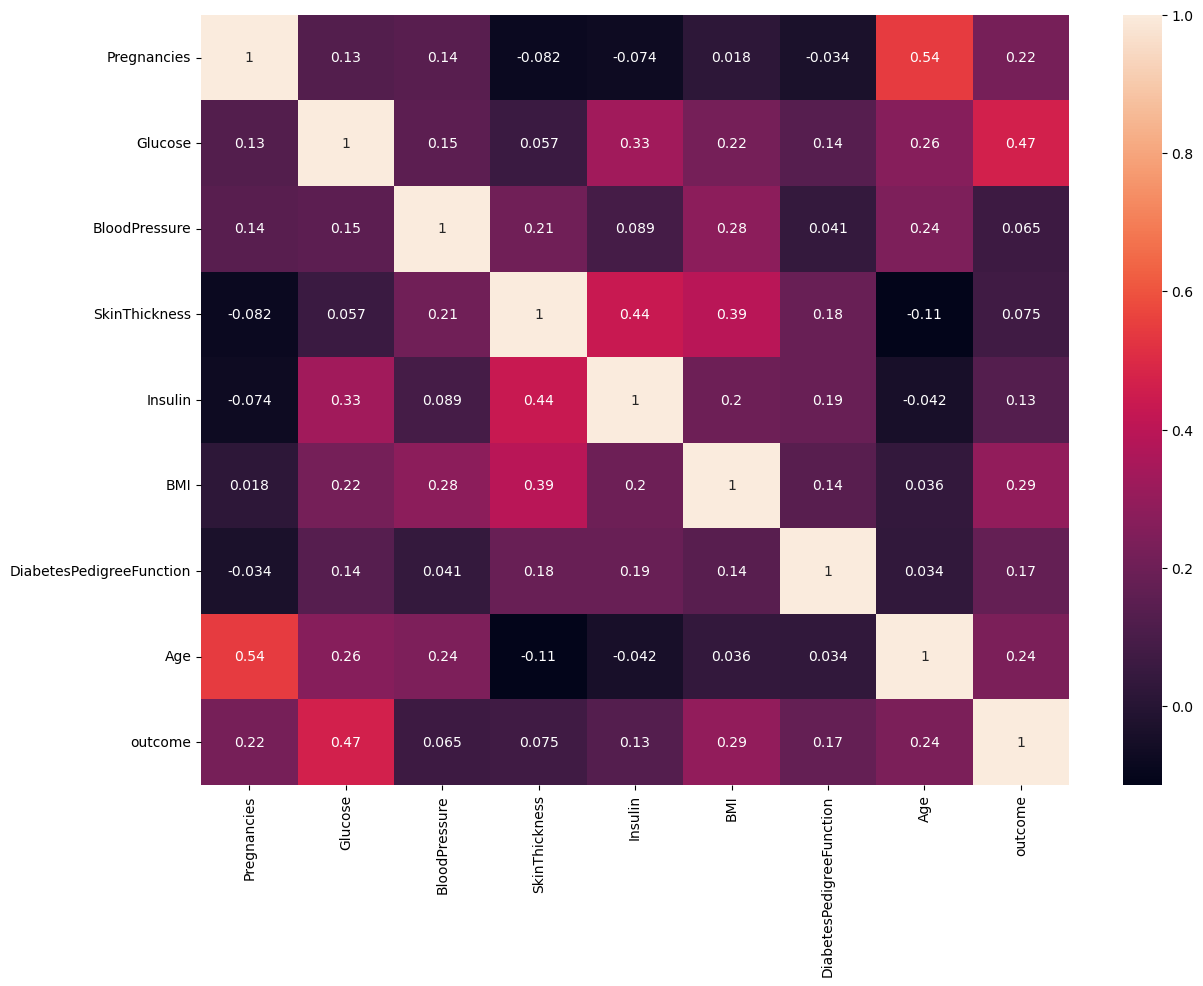

In [7]:
fig = plt.figure(figsize = (14 , 10 ))
sns.heatmap(data = df.corr() , annot = True ,)
plt.show()

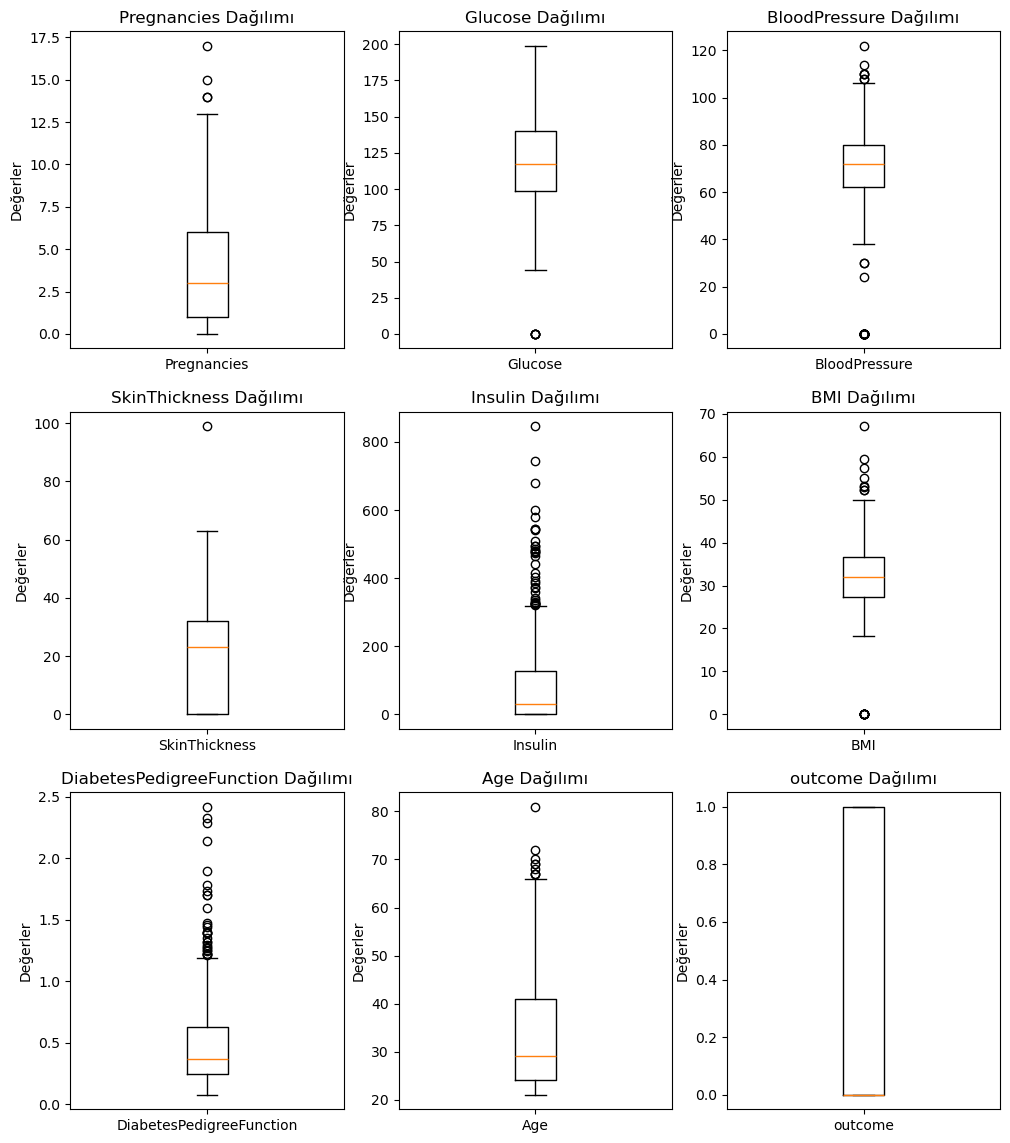

In [8]:
fig , axes = plt.subplots(ncols = 3 , nrows = 3 , figsize = (12,14))

for item , ax in enumerate(axes.flatten()) : 
    if item < len(df.columns) : 
        columns_name = df.columns[item]
        ax.boxplot(df[columns_name])
        ax.set_ylabel('Değerler')
        ax.set_title(f'{columns_name} Dağılımı')
        ax.set_xticklabels([columns_name])
plt.show()

In [9]:
df[df['BMI'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,outcome
9,8,125,96,0,0,0.0,0.232,54,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
81,2,74,0,0,0,0.0,0.102,22,0
145,0,102,75,23,0,0.0,0.572,21,0
371,0,118,64,23,89,0.0,1.731,21,0
426,0,94,0,0,0,0.0,0.256,25,0
494,3,80,0,0,0,0.0,0.174,22,0
522,6,114,0,0,0,0.0,0.189,26,0
684,5,136,82,0,0,0.0,0.640,69,0


In [10]:
columns_to_replace = ['BloodPressure' , 'SkinThickness' , 'BMI']

In [11]:
df[columns_to_replace] = df[columns_to_replace].replace(0 , np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   768 non-null    int64  
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [12]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
for col in columns_to_replace : 
    df[col].fillna(df[col].median() , inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


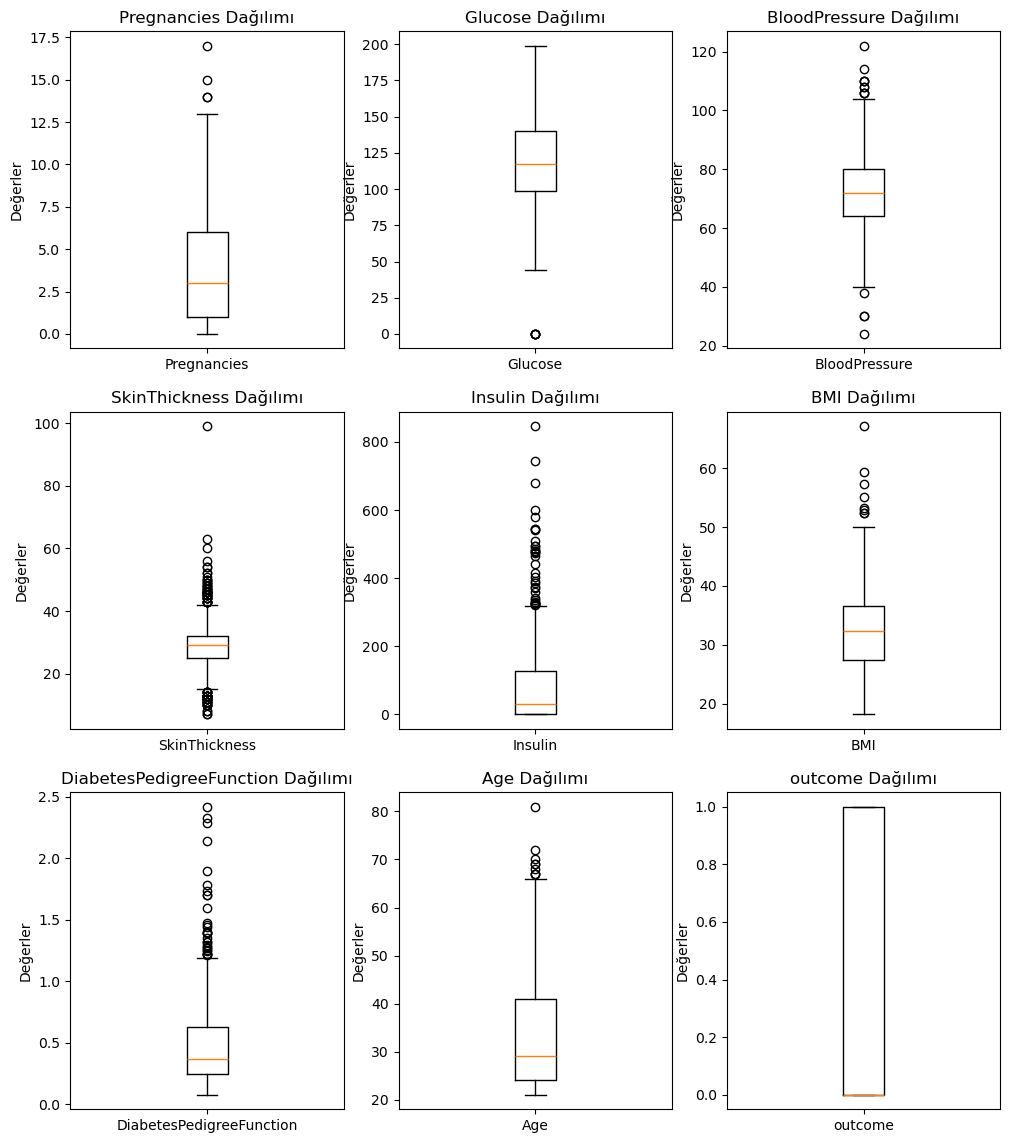

In [14]:
fig , axes = plt.subplots(ncols = 3 , nrows = 3 , figsize = (12,14))

for item , ax in enumerate(axes.flatten()) : 
    if item < len(df.columns) : 
        columns_name = df.columns[item]
        ax.boxplot(df[columns_name])
        ax.set_ylabel('Değerler')
        ax.set_title(f'{columns_name} Dağılımı')
        ax.set_xticklabels([columns_name])
plt.show()

In [15]:
# Önceki yanıtta verilen fonksiyonu kullanalım
def cap_outliers(df, col_name):
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col_name] = df[col_name].clip(lower=lower_bound, upper=upper_bound)
    return df

# Aykırı değeri olan tüm bağımsız değişkenlere bu işlemi uygulayın

# ÖNEMLİ: 'outcome' sütununa dokunmayın, o sizin hedef değişkeniniz!
outlier_columns = ["SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Pregnancies", "Glucose", "BloodPressure"]

for col in outlier_columns:
    df = cap_outliers(df, col)

# Bu işlemden sonra boxplot'ları tekrar çizerseniz,
# artık hiç yuvarlak nokta (outlier) görmemeniz gerekir.

In [16]:
df['outcome'].value_counts()

outcome
0    500
1    268
Name: count, dtype: int64

In [17]:
# Machine Learning 

In [18]:
X = df.drop('outcome' , axis = 1)
y = df['outcome']

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state = 20 , test_size = 0.3)

from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

regression = LogisticRegression()

In [23]:
regression.fit(X_train , y_train)

LogisticRegression()

In [24]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report 

In [25]:
y_pred = regression.predict(X_test)

score = accuracy_score(y_test , y_pred)
matrix = confusion_matrix(y_test , y_pred)
report = classification_report(y_test , y_pred)

print('Score : ' , score)
print('Report : \n' , report)
print('Matrix : \n' , matrix)

Score :  0.7662337662337663
Report : 
               precision    recall  f1-score   support

           0       0.78      0.90      0.84       153
           1       0.71      0.51      0.60        78

    accuracy                           0.77       231
   macro avg       0.75      0.70      0.72       231
weighted avg       0.76      0.77      0.75       231

Matrix : 
 [[137  16]
 [ 38  40]]


In [26]:
#-----HYPERPARAMETHER TUNİNG-----

In [27]:
model =LogisticRegression()

In [28]:
from sklearn.model_selection import GridSearchCV , StratifiedKFold

In [29]:
penalty = ['l1' , 'l2' , 'elasticnet']
c_values = [100 , 50 , 10 , 0.1 , 0.01]
solver =  ['lbfgs' , 'liblinear' , 'newton-cg' , 'newton-cholesky' , 'sag' , 'saga']
class_weight = [{0 : w , 1 : y} for w in [1 , 10 , 50 , 100] for y in [100 , 50 , 10 , 1]]

params = dict(penalty = penalty , C = c_values , solver = solver , class_weight = class_weight)

In [30]:
cv = StratifiedKFold(n_splits = 5 )
grid = GridSearchCV(estimator = model , param_grid = params , scoring = 'accuracy' , n_jobs = -1 , cv = cv)

In [31]:
grid.fit(X_train , y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 50, 10, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 100}, {0: 1, 1: 50},
                                          {0: 1, 1: 10}, {0: 1, 1: 1},
                                          {0: 10, 1: 100}, {0: 10, 1: 50},
                                          {0: 10, 1: 10}, {0: 10, 1: 1},
                                          {0: 50, 1: 100}, {0: 50, 1: 50},
                                          {0: 50, 1: 10}, {0: 50, 1: 1},
                                          {0: 100, 1: 100}, {0: 100, 1: 50},
                                          {0: 100, 1: 10}, {0: 100, 1: 1}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='accuracy')

In [32]:
y_pred_grid = grid.predict(X_test)

score = accuracy_score(y_test , y_pred_grid)
matrix = confusion_matrix(y_test , y_pred_grid)
classification = classification_report(y_test , y_pred_grid)

print('Accuracy Score : ' , score)
print('Classification :\n ' , classification)
print('Matrix : \n' , matrix)

Accuracy Score :  0.7619047619047619
Classification :
                precision    recall  f1-score   support

           0       0.78      0.89      0.83       153
           1       0.70      0.51      0.59        78

    accuracy                           0.76       231
   macro avg       0.74      0.70      0.71       231
weighted avg       0.75      0.76      0.75       231

Matrix : 
 [[136  17]
 [ 38  40]]


In [33]:
grid.best_score_

np.float64(0.7745586708203531)

In [37]:
grid.best_params_

{'C': 0.1,
 'class_weight': 'balanced',
 'l1_ratio': np.float64(0.75),
 'penalty': 'elasticnet',
 'solver': 'saga'}

In [41]:
# ----------- SMOOTE ETME DENEYELİM ------------

In [42]:
from imblearn.over_sampling import SMOTE

In [47]:
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state = 20 , test_size = 0.3)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state = 40)
X_train_resampled , y_train_resampled = smote.fit_resample(X_train_scaled , y_train ) 

pd.Series(y_train_resampled).value_counts()

0    464
1    464
Name: count, dtype: int64

In [49]:
model = LogisticRegression()

cv = StratifiedKFold()

penalty = ['l1' , 'l2' , 'elasticnet']
c_values = [20 , 10 , 1 , 0 , 0.1]
solver = ['sag' , 'saga' , 'liblinear' , 'lbfgs' , 'newton-cg' , 'newton-cholesky']
l1_ratio = [0.25 , 0.75 , 0.5]

params = dict(penalty = penalty , C = c_values , solver = solver , l1_ratio = l1_ratio)

grid = GridSearchCV(estimator = model , param_grid = params , n_jobs = -1 , cv = cv )

grid.fit(X_train_resampled , y_train_resampled)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [20, 10, 1, 0, 0.1],
                         'l1_ratio': [0.25, 0.75, 0.5],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['sag', 'saga', 'liblinear', 'lbfgs',
                                    'newton-cg', 'newton-cholesky']})

In [54]:
y_pred = grid.predict(X_test_scaled)

print('Classification Report  : \n' , classification_report(y_test , y_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , y_pred))ss
print('Accuracy Score : \n' , accuracy_score(y_test , y_pred))# Model gerçek hayatta karşılaştığı verilere test edilidiğinde elde edilen score

Classification Report  : 
               precision    recall  f1-score   support

           0       0.88      0.81      0.85       198
           1       0.69      0.79      0.74       102

    accuracy                           0.81       300
   macro avg       0.79      0.80      0.79       300
weighted avg       0.82      0.81      0.81       300

Confusion Matrix : 
 [[161  37]
 [ 21  81]]
Accuracy Score : 
 0.8066666666666666


In [55]:
grid.best_params_

{'C': 0.1, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}

In [56]:
grid.best_score_  # Model eğitimi sırasında alınan en yüksek score

np.float64(0.8265271723336239)